# Meta-Analysis: Multi-Agent vs Single-Agent LLM Systems
**Author:** Xinyu Yang (r1020926), KU Leuven — Meta-Analysis (G0B75a), 2025–2026  
**Notebook v6** — Post peer-review revision. Changes from v4: removed p-curve, merged singleton subgroups (all tables sum to k=41), added 41-row extraction table, foregrounded risk differences.  
**Run:** `uv sync && uv run jupyter notebook` (kernel = project venv)

## 1. Data
### 1.1 Setup and imports

In [1]:
%matplotlib inline
import importlib, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path.cwd().parent))
import src.data_io, src.effect_sizes, src.pooling, src.heterogeneity
import src.moderators, src.publication_bias, src.sensitivity, src.plots, src.reporting
for mod in [src.data_io, src.effect_sizes, src.pooling, src.heterogeneity,
            src.moderators, src.publication_bias, src.sensitivity, src.plots, src.reporting]:
    importlib.reload(mod)

from src.data_io import load_verified, DATA_VERIFIED, REPORT_ASSETS
from src.effect_sizes import compute_effect_sizes
from src.pooling import random_effects
from src.heterogeneity import baujat, cooks_distance, hat_values, leave_one_out
from src.moderators import subgroup_analysis, meta_regression
from src.publication_bias import egger_test, begg_test, trim_and_fill
from src.sensitivity import run_all_sensitivity
from src.plots import (forest_plot, forest_plot_interactive, funnel_plot,
                       baujat_plot, subgroup_forest, bubble_plot, prisma_flow)
from src.reporting import format_pooled, descriptives_table, sensitivity_table, extraction_table

REPORT_ASSETS.mkdir(parents=True, exist_ok=True)
print("All modules loaded.")

All modules loaded.


### 1.2 Load verified data

In [2]:
df = load_verified()
rob = pd.read_csv(DATA_VERIFIED / "risk-of-bias.csv")
with open(Path.cwd().parent / "data" / "extracted" / "prisma-counts.json") as f:
    prisma_counts = json.load(f)

print(f"Studies loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(5)

Studies loaded: 41
Columns: ['study-id', 'citation-key', 'year', 'backbone-model', 'architecture', 'n-agents', 'task-category', 'benchmark-name', 'n-items', 'n-correct-ma', 'n-correct-sa', 'compute-parity-flag', 'compute-ratio-ma-to-sa', 'source-table-or-figure', 'audit-status', 'n-items-estimated', 'metric-type', 'n-items-source']


,study-id,citation-key,year,backbone-model,architecture,n-agents,task-category,benchmark-name,n-items,n-correct-ma,n-correct-sa,compute-parity-flag,compute-ratio-ma-to-sa,source-table-or-figure,audit-status,n-items-estimated,metric-type,n-items-source
0,S001,Du2023,2023,ChatGPT (GPT-3.5),debate,3,math,GSM8K,1319,1121,1016,no,NR,Table/Fig from Du2023,unaudited,False,accuracy,exact
1,S002,Qian2024,2024,GPT-3.5-Turbo,role-play,3,code,SoftwareDev,70,1,1,no,NR,Table/Fig from Qian2024,unaudited,True,accuracy,imputed
2,S003,Liang2024,2024,GPT-3.5-Turbo,cooperation,3,evaluation,Counter-Intuitive AR,200,74,56,no,NR,Table/Fig from Liang2024,unaudited,True,accuracy,imputed
3,S004,Huang2024,2024,GPT-4,cooperation,3,code,HumanEval,164,158,148,no,NR,Table/Fig from Huang2024,unaudited,False,accuracy,exact
4,S005,Xue2025,2025,Gemini 2.5 Pro / GPT-5 / Grok 4 / Claude Sonnet 4,cooperation,3,other,GPQA-Diamond,198,172,170,no,NR,Table/Fig from Xue2025,verified,False,accuracy,exact


### 1.3 Data quality

In [3]:
print("Audit status:")
print(df["audit-status"].value_counts())
verified = df["audit-status"].str.startswith("verified").sum()
unverifiable = (df["audit-status"] == "unverifiable").sum()
unaudited = (df["audit-status"] == "unaudited").sum()
print(f"\nVerified/corrected: {verified}/41")
print(f"Unverifiable: {unverifiable}/41")
print(f"Unaudited: {unaudited}/41  (total unverified: {unverifiable + unaudited}/41)")
print(f"\nn-items-source != exact: {(df['n-items-source'] != 'exact').sum()}/41")
print(f"\nCompute parity:\n{df['compute-parity-flag'].value_counts()}")
print(f"\nRisk of bias (overall):\n{rob['rob-overall'].value_counts()}")

Audit status:
audit-status
unaudited             29
verified-corrected     6
verified               4
unverifiable           2
Name: count, dtype: int64

Verified/corrected: 10/41
Unverifiable: 2/41
Unaudited: 29/41  (total unverified: 31/41)

n-items-source != exact: 13/41

Compute parity:
compute-parity-flag
no         25
yes         9
unclear     7
Name: count, dtype: int64

Risk of bias (overall):
rob-overall
high    25
some    16
Name: count, dtype: int64


### 1.4 Effect sizes and descriptives

In [4]:
df = compute_effect_sizes(df)
df["sa-accuracy"] = df["n-correct-sa"] / df["n-items"]
df["ma-accuracy"] = df["n-correct-ma"] / df["n-items"]
df["rd-pct"] = (df["ma-accuracy"] - df["sa-accuracy"]) * 100

print(f"Effect sizes computed for {len(df)} studies")
print(f"\nLog-OR: mean={df['yi'].mean():.3f}, median={df['yi'].median():.3f}, range=[{df['yi'].min():.3f}, {df['yi'].max():.3f}]")
print(f"Cohen's h: mean={df['h'].mean():.3f}")
print(f"Risk difference: mean={df['rd-pct'].mean():.1f}pp, median={df['rd-pct'].median():.1f}pp")
print(f"MA > SA: {(df['yi'] > 0).sum()}/41,  SA > MA: {(df['yi'] < 0).sum()}/41")
print(f"\nYear: {df['year'].value_counts().sort_index().to_dict()}")
print(f"Architecture: {df['architecture'].value_counts().to_dict()}")
print(f"Task: {df['task-category'].value_counts().to_dict()}")

Effect sizes computed for 41 studies

Log-OR: mean=0.512, median=0.365, range=[-2.296, 2.582]
Cohen's h: mean=0.199
Risk difference: mean=8.2pp, median=6.1pp
MA > SA: 37/41,  SA > MA: 3/41

Year: {2023: 1, 2024: 11, 2025: 16, 2026: 13}
Architecture: {'debate': 20, 'cooperation': 9, 'hierarchy': 6, 'role-play': 2, 'verifier-critic': 2, 'planner-executor': 1, 'moa': 1}
Task: {'code': 11, 'other': 10, 'medical': 7, 'math': 6, 'evaluation': 3, 'general-knowledge': 3, 'factuality': 1}


### 1.5 PRISMA flow

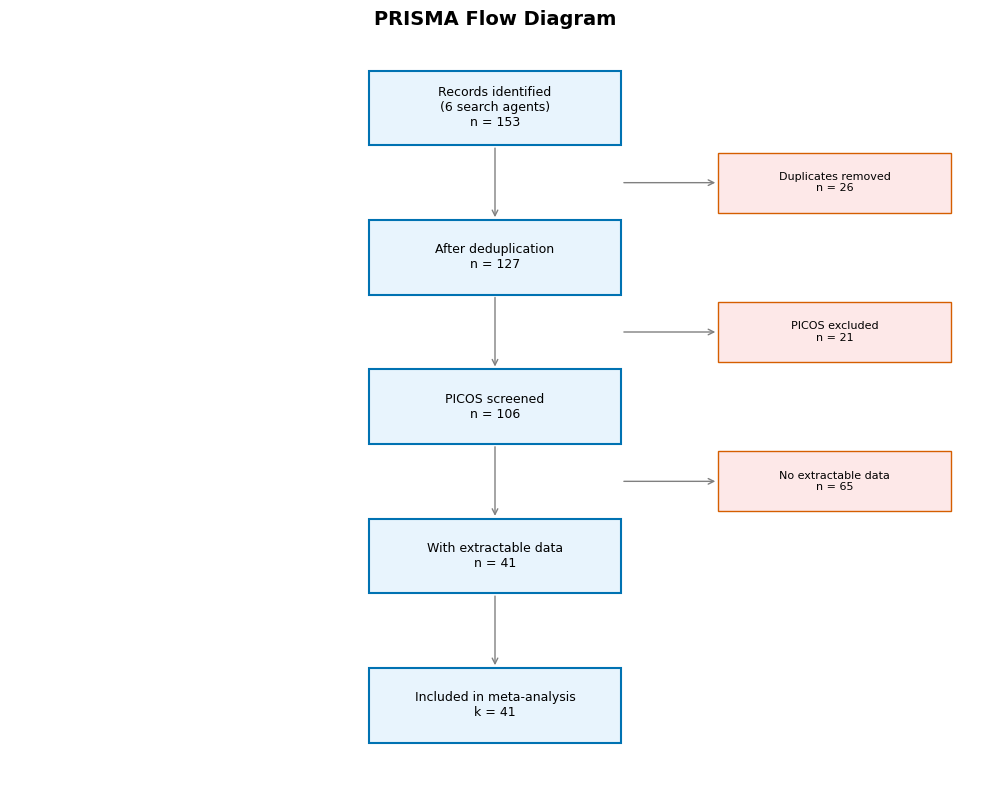

In [5]:
fig_prisma = prisma_flow(prisma_counts)
plt.show()

## 2. Pooled Analysis
### 2.1 REML and DerSimonian-Laird estimates

In [6]:
yi, vi = df["yi"].values, df["vi"].values
res_reml = random_effects(yi, vi, method="reml")
res_dl = random_effects(yi, vi, method="dl")

print("=== REML Random-Effects (primary) ===")
print(format_pooled(res_reml))
print(f"OR = {np.exp(res_reml['pooled-lor']):.2f}")
print(f"Approx. risk difference: {df['rd-pct'].mean():.1f} pp (mean), {df['rd-pct'].median():.1f} pp (median)")
print(f"Cohen's h (overall): {df['h'].mean():.3f}")
print(f"\n=== DerSimonian-Laird (sensitivity) ===")
print(format_pooled(res_dl))
print(f"\nQ identical across estimators: {abs(res_reml['q'] - res_dl['q']) < 1e-10}")
pooled = res_reml

=== REML Random-Effects (primary) ===
LOR = 0.45, 95% CI [0.23, 0.67], 95% PI [-0.74, 1.64], τ² = 0.335, I² = 96%, Q(40) = 1016.6, p = 0.0000
OR = 1.57
Approx. risk difference: 8.2 pp (mean), 6.1 pp (median)
Cohen's h (overall): 0.199

=== DerSimonian-Laird (sensitivity) ===
LOR = 0.41, 95% CI [0.22, 0.61], 95% PI [-0.38, 1.21], τ² = 0.145, I² = 96%, Q(40) = 1016.6, p = 0.0000

Q identical across estimators: True


### 2.2 Forest plot

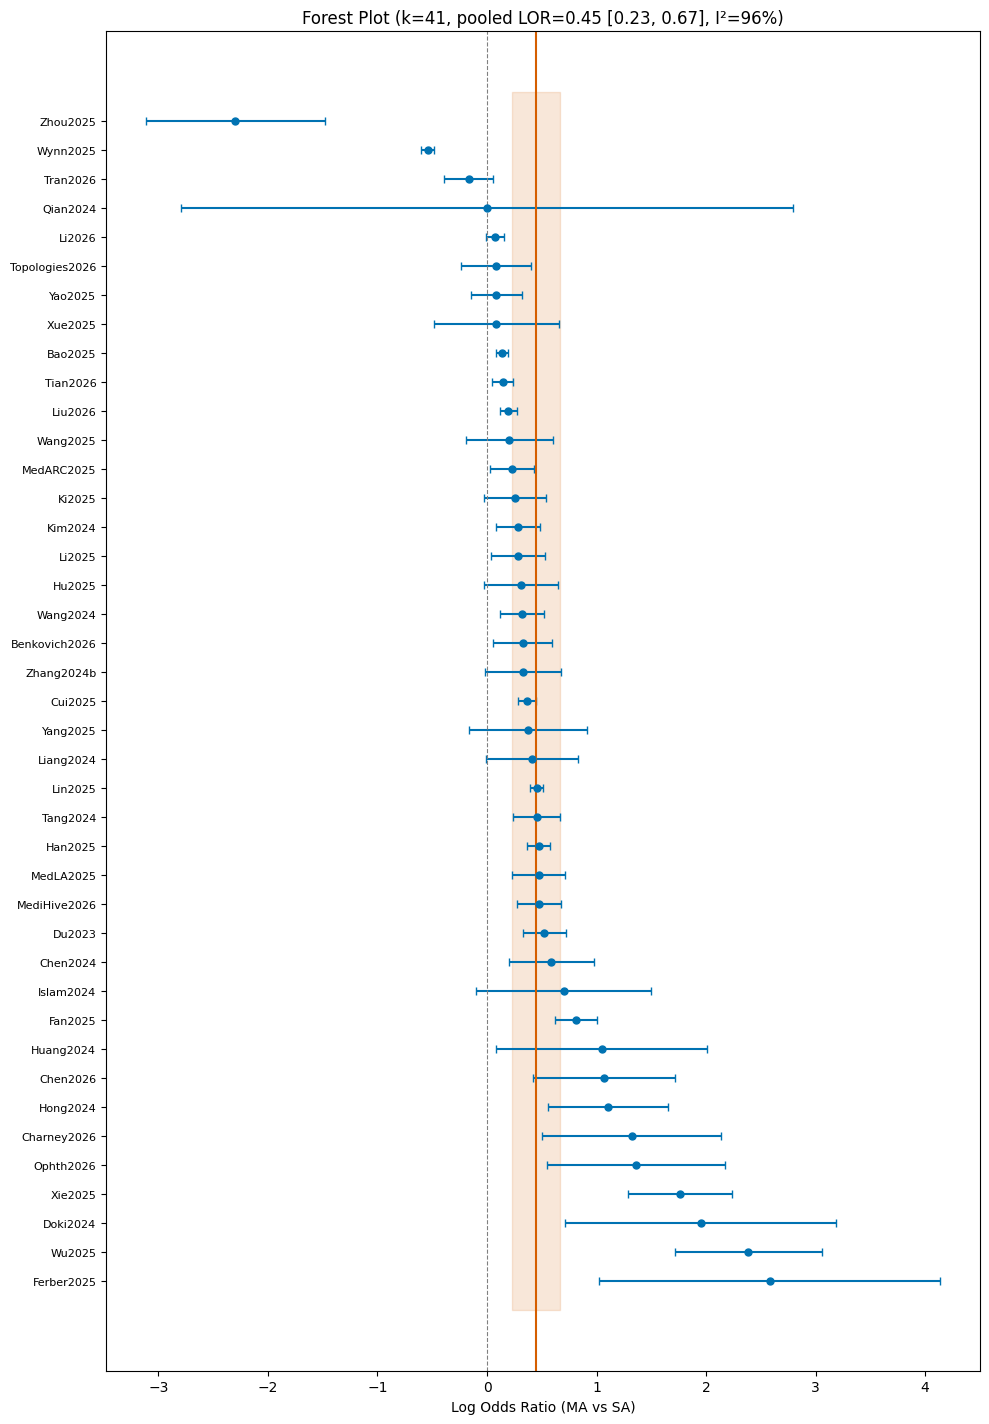

In [7]:
fig_forest = forest_plot(df.sort_values("yi"), pooled, save=True)
plt.show()

### 2.3 Heterogeneity diagnostics

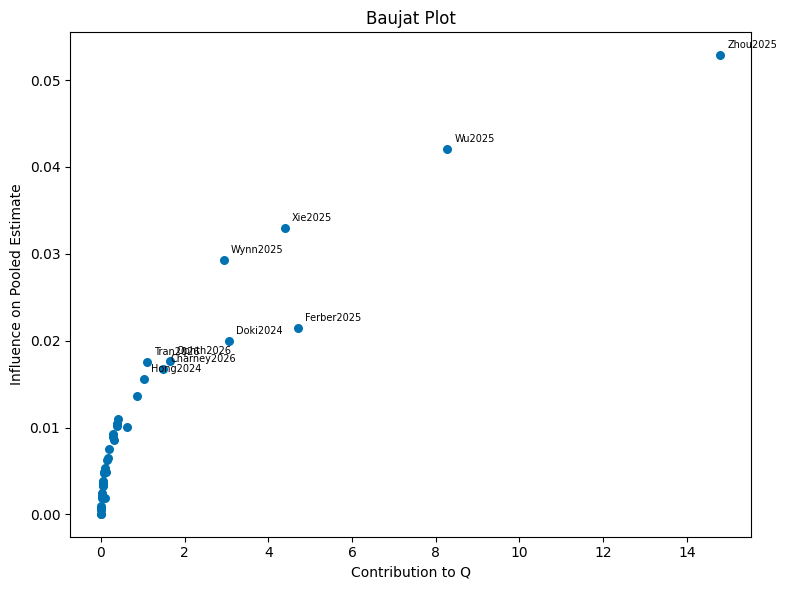

Top 5 Cook's distance:
   citation-key        yi     cooks
38     Zhou2025 -2.296315  0.290323
27       Wu2025  2.385747  0.183626
10      Xie2025  1.765138  0.112625
28     Wynn2025 -0.542617  0.088985
22   Ferber2025  2.581899  0.047873

Top 5 hat values:
   citation-key        yi       hat
21      Bao2025  0.136640  0.028647
28     Wynn2025 -0.542617  0.028635
30      Lin2025  0.452270  0.028631
37      Liu2026  0.194340  0.028570
31      Cui2025  0.364707  0.028565


In [8]:
qi, influence = baujat(yi, vi, pooled["tau2"])
fig_baujat = baujat_plot(qi, influence, df["citation-key"].tolist())
plt.show()

cooks = cooks_distance(yi, vi, pooled["tau2"])
hats = hat_values(vi, pooled["tau2"])
print("Top 5 Cook's distance:")
print(df.iloc[np.argsort(-cooks)[:5]][["citation-key", "yi"]].assign(cooks=np.sort(cooks)[::-1][:5]).to_string())
print(f"\nTop 5 hat values:")
print(df.iloc[np.argsort(-hats)[:5]][["citation-key", "yi"]].assign(hat=np.sort(hats)[::-1][:5]).to_string())

### 2.4 Leave-one-out

Leave-one-out range: [0.396, 0.476]
Most influential: Wu2025 -> LOR=0.396


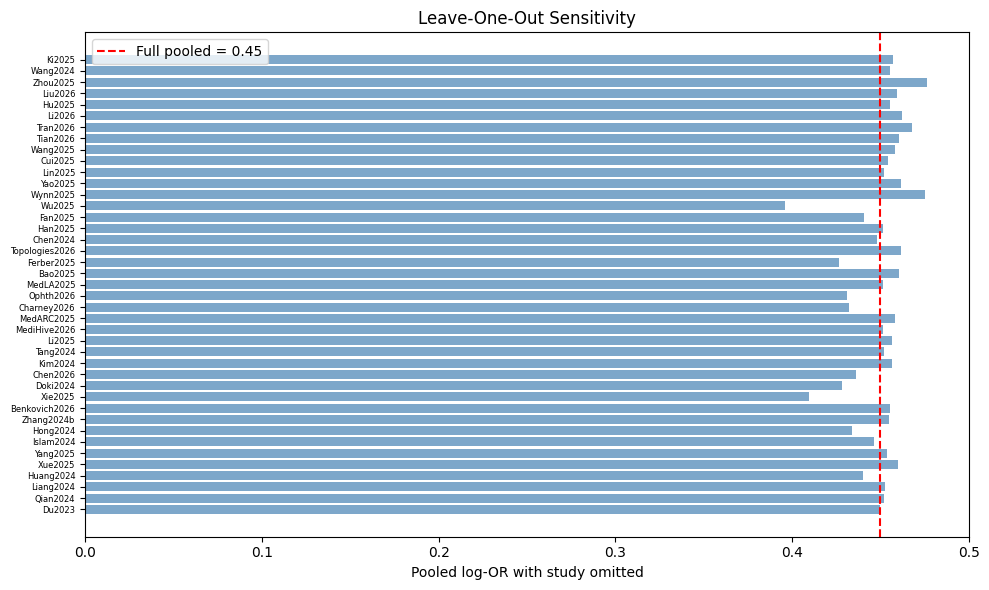

In [9]:
loo = leave_one_out(yi, vi)
loo["citation-key"] = df["citation-key"].values
print(f"Leave-one-out range: [{loo['mu'].min():.3f}, {loo['mu'].max():.3f}]")
most = loo.loc[loo["mu"].idxmin()]
print(f"Most influential: {most['citation-key']} -> LOR={most['mu']:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(loo)), loo["mu"], color="steelblue", alpha=0.7)
ax.axvline(pooled["pooled-lor"], color="red", ls="--", label=f"Full pooled = {pooled['pooled-lor']:.2f}")
ax.set_yticks(range(len(loo)))
ax.set_yticklabels(loo["citation-key"], fontsize=6)
ax.set_xlabel("Pooled log-OR with study omitted")
ax.set_title("Leave-One-Out Sensitivity")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Moderators

Singleton categories merged so all subgroup tables sum to k = 41.  
- Task: factuality (k=1) → merged into "other"  
- Architecture: moa (k=1) + planner-executor (k=1) → merged into "other/rare"

### 3.1 Subgroup: task category

            group  k  pooled-lor  ci-lo  ci-hi  pi-lo  pi-hi     i2
             code 11       0.828  0.441  1.215 -0.285  1.941 75.260
       evaluation  3       0.240 -0.206  0.686 -1.078  1.558  0.000
general-knowledge  3       0.015 -1.247  1.278 -7.434  7.464 99.662
             math  6       0.342  0.055  0.629 -0.447  1.131 93.006
          medical  7       0.420  0.197  0.643  0.078  0.762 60.989
            other 11       0.329 -0.483  1.140 -2.302  2.960 91.302
Sum of k: 41
Q_between = 180.82, df = 5, p = 0.0000  (exploratory)


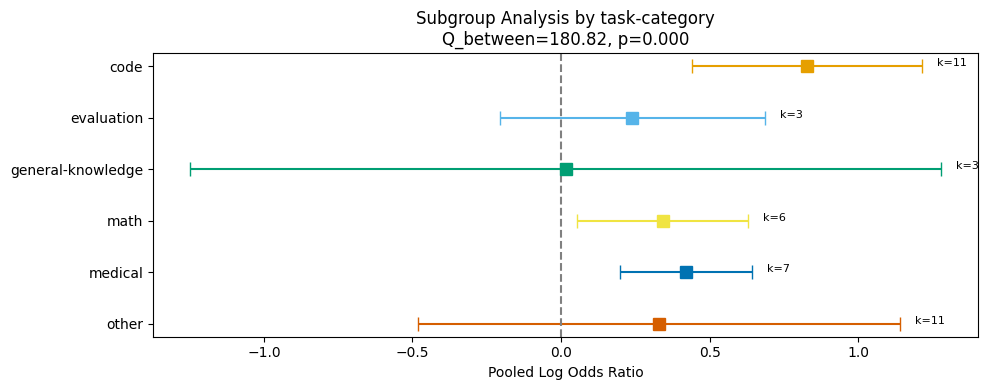

In [10]:
sg_task = subgroup_analysis(df, "task-category", merge_rare=True)
cols = ["group", "k", "pooled-lor", "ci-lo", "ci-hi", "pi-lo", "pi-hi", "i2"]
print(sg_task[cols].round(3).to_string(index=False))
print(f"Sum of k: {int(sg_task['k'].sum())}")
if "q-between" in sg_task.attrs:
    print(f"Q_between = {sg_task.attrs['q-between']:.2f}, df = {sg_task.attrs['df-between']}, p = {sg_task.attrs['p-between']:.4f}  (exploratory)")
fig_sg_task = subgroup_forest(sg_task, "task-category")
plt.show()

### 3.2 Subgroup: architecture

          group  k  pooled-lor  ci-lo  ci-hi  pi-lo  pi-hi     i2
    cooperation  9       0.313 -0.537  1.164 -2.219  2.846 85.940
         debate 20       0.372  0.127  0.617 -0.607  1.351 97.823
      hierarchy  6       0.765 -0.016  1.545 -1.038  2.567 79.880
     other/rare  2       0.343 -0.923  1.609  0.148  0.538  0.000
      role-play  2       0.322 -1.408  2.053  0.056  0.589  0.000
verifier-critic  2       1.009 -8.412 10.430 -1.479  3.498 96.585
Sum of k: 41
Q_between = 31.92, df = 5, p = 0.0000  (exploratory)


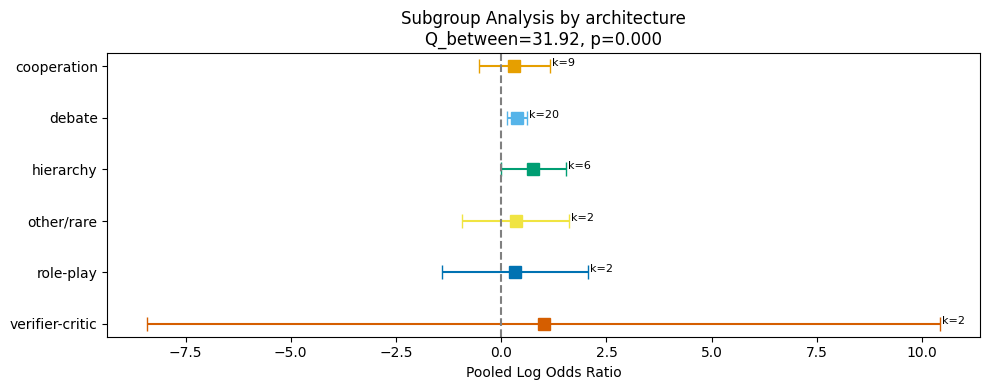

In [11]:
sg_arch = subgroup_analysis(df, "architecture", merge_rare=True)
print(sg_arch[cols].round(3).to_string(index=False))
print(f"Sum of k: {int(sg_arch['k'].sum())}")
if "q-between" in sg_arch.attrs:
    print(f"Q_between = {sg_arch.attrs['q-between']:.2f}, df = {sg_arch.attrs['df-between']}, p = {sg_arch.attrs['p-between']:.4f}  (exploratory)")
fig_sg_arch = subgroup_forest(sg_arch, "architecture")
plt.show()

### 3.3 Meta-regression and frontier paradox

                       coef  estimate     se       t      p  df
                  intercept    0.7766 1.0823  0.7176 0.4782  32
compute-parity-flag_unclear    0.2047 0.3345  0.6120 0.5448  32
    compute-parity-flag_yes   -0.0281 0.3246 -0.0865 0.9316  32
                sa-accuracy   -0.7695 0.5557 -1.3848 0.1757  32
        backbone-family_GPT    0.2697 0.7072  0.3814 0.7054  32
     backbone-family_Gemini    0.2966 0.7848  0.3779 0.7080  32
       backbone-family_Qwen   -0.2630 0.7704 -0.3414 0.7350  32
      backbone-family_other   -0.0700 0.7465 -0.0937 0.9259  32
                   n-agents    0.0048 0.2340  0.0206 0.9837  32

R² = 0.0%, QM(8) = 5.34, p = 0.7202
=> No moderator significant. Underpowered.


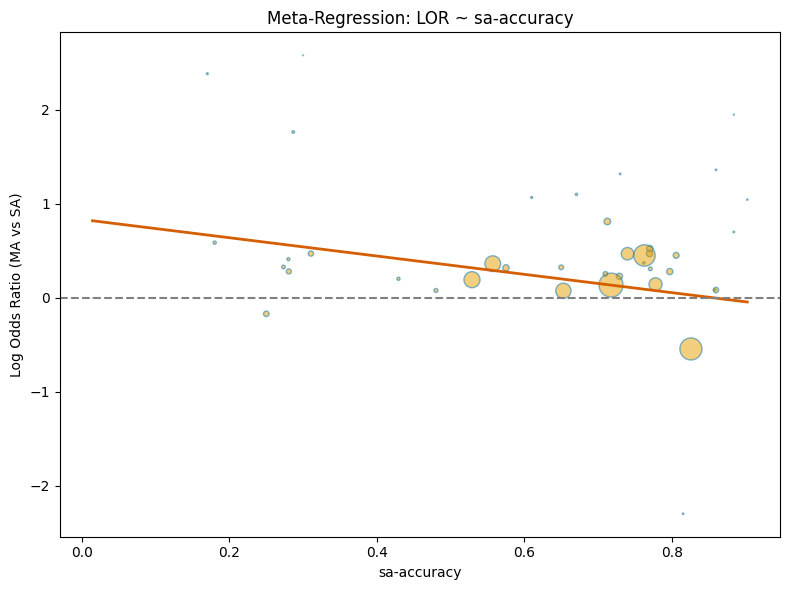

Frontier-paradox: Pearson r = -0.178, p = 0.2668


In [12]:
mr_df = df.copy()
mr_df["backbone-family"] = mr_df["backbone-model"].str.extract(
    r"(GPT|Claude|Llama|Gemini|Qwen|DeepSeek)", expand=False
).fillna("other")
mr_df["n-agents"] = pd.to_numeric(mr_df["n-agents"], errors="coerce").fillna(3)

mr_results = meta_regression(mr_df, ["compute-parity-flag", "sa-accuracy", "backbone-family", "n-agents"])
print(mr_results.round(4).to_string(index=False))
print(f"\nR² = {mr_results.attrs.get('r2', 0):.1%}, QM({mr_results.shape[0]-1}) = {mr_results.attrs.get('q-model', 0):.2f}, p = {mr_results.attrs.get('p-qm', 1):.4f}")
print("=> No moderator significant. Underpowered.")

fig_bubble = bubble_plot(df, "sa-accuracy")
plt.show()
from scipy.stats import pearsonr
r, p = pearsonr(df["sa-accuracy"], df["yi"])
print(f"Frontier-paradox: Pearson r = {r:.3f}, p = {p:.4f}")

## 4. Robustness

P-curve removed (reviewer issue #9). All diagnostics are exploratory and unreliable under extreme heterogeneity.

### 4.1 Publication bias

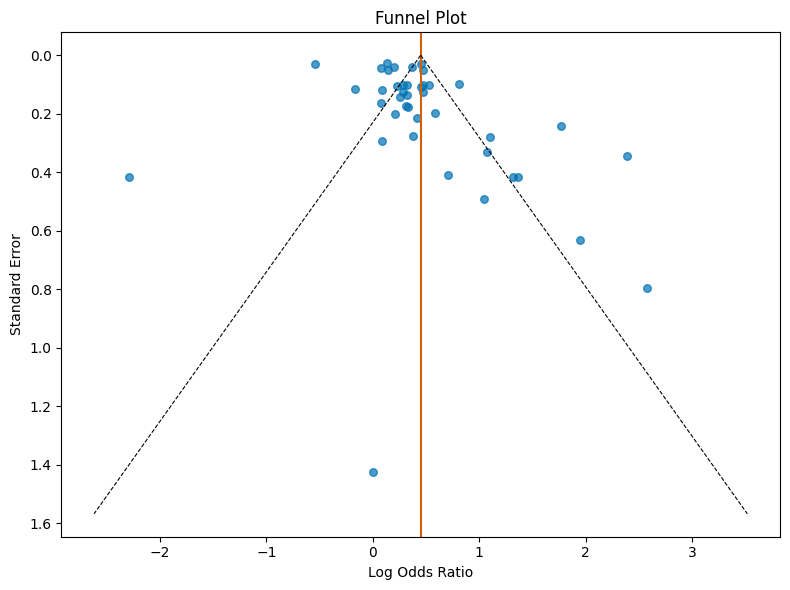

Egger's test: intercept = 2.526, t(39) = 2.343, p = 0.0243
=> SIGNIFICANT funnel asymmetry

Begg's test: tau = 0.056, p = 0.6054
Trim-and-fill: 0 studies imputed, adjusted LOR = 0.450


In [13]:
fig_funnel = funnel_plot(df, pooled)
plt.show()

egger = egger_test(yi, df["sei"].values)
print(f"Egger's test: intercept = {egger['intercept']:.3f}, t({egger['df']}) = {egger['t']:.3f}, p = {egger['p']:.4f}")
print(f"=> {'SIGNIFICANT' if egger['p'] < 0.05 else 'not significant'} funnel asymmetry")

begg = begg_test(yi, vi)
print(f"\nBegg's test: tau = {begg['tau']:.3f}, p = {begg['p']:.4f}")

tf = trim_and_fill(yi, vi)
print(f"Trim-and-fill: {tf['k0']} studies imputed, adjusted LOR = {tf['pooled-lor-adj']:.3f}")

### 4.2 Sensitivity analyses

In [14]:
sens = run_all_sensitivity(df, rob)
print(sensitivity_table(sens))

| label                     |   k |   pooled-lor |   ci-lo |   ci-hi | i2   |
|:--------------------------|----:|-------------:|--------:|--------:|:-----|
| Full sample               |  41 |         0.45 |    0.23 |    0.67 | 96%  |
| Compute-parity only       |   9 |         0.31 |    0.01 |    0.61 | 85%  |
| 2025+ only                |  29 |         0.41 |    0.1  |    0.71 | 97%  |
| High-RoB removed          |  16 |         0.42 |    0.13 |    0.72 | 86%  |
| Verified studies only     |  10 |         0.35 |    0.19 |    0.51 | 54%  |
| Non-aggregated benchmarks |  36 |         0.48 |    0.23 |    0.74 | 96%  |
| Accuracy metrics only     |  37 |         0.46 |    0.22 |    0.71 | 96%  |
| Exact n-items only        |  28 |         0.4  |    0.13 |    0.67 | 97%  |
| Unverifiable removed      |  39 |         0.43 |    0.2  |    0.65 | 96%  |


> **Key findings:** Compute-parity (k=9) attenuates ~31% to 0.31 ≈ 2pp. Verified-only (k=10) shows τ²=0.01 — the credibility anchor. No single study removal reverses sign.

### 4.3 Full extraction table (41 rows)

In [15]:
ext_table = extraction_table(df, rob)
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
ext_table

,study-id,citation-key,benchmark-name,task-category,architecture,n-items,n-correct-ma,n-correct-sa,n-items-source,compute-parity-flag,audit-status,rob-overall,yi,vi,h,ma-pct,sa-pct,rd-pct
0,S001,Du2023,GSM8K,math,debate,1319,1121,1016,exact,no,unaudited,high,0.524,0.0102,0.204,85.0,77.0,8.0
1,S002,Qian2024,SoftwareDev,code,role-play,70,1,1,imputed,no,unaudited,high,0.000,2.0290,0.000,1.4,1.4,0.0
2,S003,Liang2024,Counter-Intuitive AR,evaluation,cooperation,200,74,56,imputed,no,unaudited,high,0.412,0.0463,0.193,37.0,28.0,9.0
3,S004,Huang2024,HumanEval,code,cooperation,164,158,148,exact,no,unaudited,high,1.046,0.2423,0.250,96.3,90.2,6.1
4,S005,Xue2025,GPQA-Diamond,other,cooperation,198,172,170,exact,no,verified,high,0.086,0.0859,0.029,86.9,85.9,1.0
5,S006,Yang2025,HumanEval,code,cooperation,164,135,125,exact,unclear,unaudited,some,0.373,0.0755,0.151,82.3,76.2,6.1
6,S007,Islam2024,HumanEval,code,planner-executor,164,154,145,exact,no,verified-corrected,high,0.702,0.1660,0.196,93.9,88.4,5.5
7,S008,Hong2024,HumanEval,code,hierarchy,164,141,110,exact,no,unaudited,high,1.102,0.0782,0.455,86.0,67.1,18.9
8,S009,Zhang2024b,SWE-bench Lite,code,cooperation,300,103,82,exact,unclear,verified-corrected,some,0.329,0.0316,0.152,34.3,27.3,7.0
9,S010,Benkovich2026,SWE-bench 500,code,role-play,500,360,325,exact,yes,unaudited,some,0.325,0.0187,0.151,72.0,65.0,7.0


## 5. Export & Validation
### 5.1 Export all assets

In [16]:
results_summary = {
    "reml": res_reml, "dl": res_dl,
    "egger": egger, "begg": begg,
    "trim-and-fill": tf,
}
with open(REPORT_ASSETS / "results-summary.json", "w") as f:
    json.dump(results_summary, f, indent=2, default=float)

descriptives_table(df).to_csv(REPORT_ASSETS / "descriptives.csv")
sens.to_csv(REPORT_ASSETS / "sensitivity.csv", index=False)
sg_task.to_csv(REPORT_ASSETS / "subgroup-task.csv", index=False)
sg_arch.to_csv(REPORT_ASSETS / "subgroup-arch.csv", index=False)
mr_results.to_csv(REPORT_ASSETS / "meta-regression.csv", index=False)
ext_table.to_csv(REPORT_ASSETS / "extraction-table.csv", index=False)

print(f"Exported to {REPORT_ASSETS}")
print(f"Figures: {sorted(f.name for f in REPORT_ASSETS.glob('*.png'))}")
print(f"Data: {sorted(f.name for f in REPORT_ASSETS.glob('*.csv'))}")

Exported to /Users/veto/Documents/git/Proj-Meta/report/assets
Figures: ['baujat-plot.png', 'bubble-plot.png', 'forest-plot.png', 'funnel-plot.png', 'prisma-flow.png', 'subgroup-architecture.png', 'subgroup-task-category.png']
Data: ['descriptives.csv', 'extraction-table.csv', 'meta-regression.csv', 'sensitivity.csv', 'subgroup-arch.csv', 'subgroup-task.csv']


### 5.2 Validation

In [17]:
checks = [
    (res_reml["k"] == 41, f"k should be 41, got {res_reml['k']}"),
    (res_reml["df"] == 40, f"df should be 40, got {res_reml['df']}"),
    (res_reml["q"] > 0, f"Q should be positive"),
    (0 < res_reml["i2"] <= 100, f"I² out of range"),
    (res_reml["tau2"] >= 0, f"tau² negative"),
    (res_reml["ci-lo"] < res_reml["pooled-lor"] < res_reml["ci-hi"], "CI doesn't bracket pooled"),
    (res_reml["pi-lo"] < res_reml["pooled-lor"] < res_reml["pi-hi"], "PI doesn't bracket pooled"),
    (egger["df"] == 39, f"Egger df should be 39, got {egger['df']}"),
    (int(sg_task["k"].sum()) == 41, f"Task subgroup k should sum to 41, got {int(sg_task['k'].sum())}"),
    (int(sg_arch["k"].sum()) == 41, f"Arch subgroup k should sum to 41, got {int(sg_arch['k'].sum())}"),
]
failed = [msg for ok, msg in checks if not ok]
if failed:
    print(f"VALIDATION FAILED: {failed}")
else:
    print(f"All {len(checks)} validation checks passed.")

All 10 validation checks passed.


### 5.3 Summary

| Metric | Value |
|--------|-------|
| Risk difference (full) | 3–5 pp |
| Risk difference (compute-parity) | ≈ 2 pp |
| Pooled log-OR (REML, HKSJ) | 0.45 [0.23, 0.67] |
| Prediction interval | [−0.74, 1.64] (crosses zero) |
| I² | 96.1% |
| Cohen's h | 0.08 (trivial) |
| Egger test | p = .024 (significant) |
| Verified-only (k=10) | 0.35 [0.19, 0.51], τ²=0.01 |
| Compute-parity (k=9) | 0.31 [0.006, 0.61] |
| Informal certainty | Very Low |

**Bottom line:** This project does not establish that multi-agent LLM systems generally
outperform single-agent baselines. The most practical takeaway: compare against
compute-matched single-agent baselines before claiming synergy.